In [1]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, TargetEncoder

from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier 
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, root_mean_squared_error, r2_score

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

In [3]:
x = df.drop(columns=['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'])

label = LabelEncoder()
x['Embarked'] = label.fit_transform(x['Embarked']) 
x['Sex'] = label.fit_transform(x['Sex'])

impute = SimpleImputer(strategy="median")
x = impute.fit_transform(x)

y = df['Survived']
scale = StandardScaler()
x = scale.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=76, test_size=0.2 )

In [7]:
ada = AdaBoostClassifier(n_estimators=70)
amodel = ada.fit(x_train, y_train)

grad = GradientBoostingClassifier()
gmodel = grad.fit(x_train, y_train)

xgb = XGBClassifier()
xmodel = xgb.fit(x_train, y_train)

# i am using right now only default parameters if we have to improve our model so we need to change 
# parameters and check different parameters with different values

In [8]:
a_pred = amodel.predict(x_test)

g_pred = gmodel.predict(x_test)

x_pred = xmodel.predict(x_test)

In [9]:
print(classification_report(y_test, a_pred))

              precision    recall  f1-score   support

           0       0.86      0.90      0.88       111
           1       0.83      0.76      0.79        68

    accuracy                           0.85       179
   macro avg       0.84      0.83      0.84       179
weighted avg       0.85      0.85      0.85       179



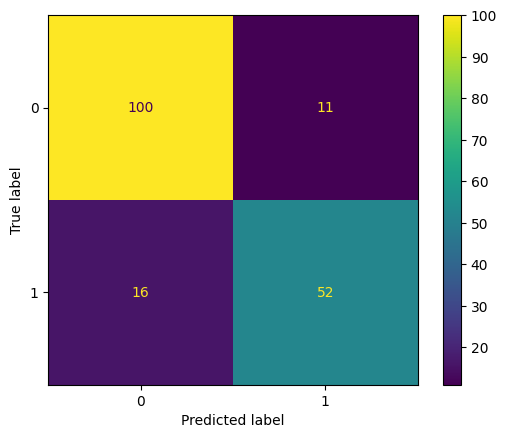

In [10]:
conf = confusion_matrix(y_test, a_pred)
ConfusionMatrixDisplay(conf).plot()

In [11]:
print(classification_report(y_test, g_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86       111
           1       0.80      0.71      0.75        68

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



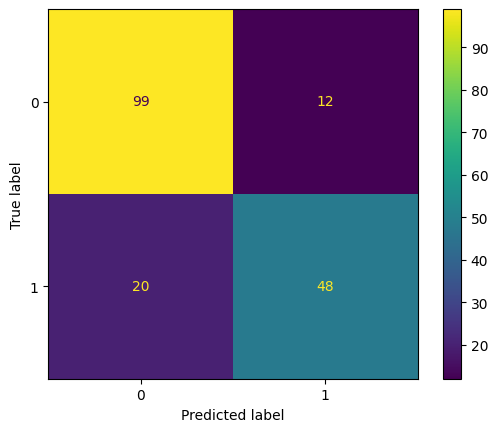

In [12]:
conf = confusion_matrix(y_test, g_pred)
ConfusionMatrixDisplay(conf).plot()